Análise de Rede Real - Rede de Aberturas de Xadrez
Dataset utilizado:  [Chess Game Dataset (Lichess)](https://www.kaggle.com/datasets/datasnaek/chess). A rede foi construída a partir dos primeiros lances de cada partida: cada nó representa uma sequência parcial de lances (uma posição de abertura), e cada aresta liga uma posição à próxima jogada feita a partir dela. Isso forma uma "árvore de aberturas".

Instale e importe as bibliotecas usandoo comando abaixo, para ter a NetworkX no ambiente do Colab (precisa ser executado só uma vez):

In [1]:
!pip install networkx

O código abaixo importa os recursos das bibliotecas utilizadas:

In [2]:
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt

 1. Depois de baixar o dataset pelo kaggle, carregue o arquivo 'games.csv' para o Colab (ícone de pasta à esquerda -> upload). Ele contém uma lista de partidas de xadrez, incluindo a coluna 'moves', com os lances de cada partida separados por espaço. Abaixo, lemos o CSV e construímos o grafo: para cada partida, pegamos os primeiros 8 lances (4 de cada jogador) e criamos os nós/arestas da árvore de aberturas.

In [5]:
df = pd.read_csv("games.csv")
N_PLIES = 8  # profundidade

G = nx.Graph()
for moves_str in df["moves"].dropna():
  lances = moves_str.split()[:N_PLIES]
  prefixo = ""
  for lance in lances:
    novo_prefixo = f"{prefixo} {lance}".strip()
    G.add_edge(prefixo if prefixo else "inicio", novo_prefixo)
    prefixo = novo_prefixo

print("rede de aberturas upada")

rede de aberturas upada


2. Medidas básicas da rede real, abaixo o código calcula e exibe a ordem, o coeficiente de agrupamento médio e a densidade da rede:

In [6]:
ordem = G.number_of_nodes()
tamanho = G.number_of_edges()
coef_agrupamento = nx.average_clustering(G)
densidade = nx.density(G)

print("aberturas de xadrez")
print(f"ordem (numero de posicoes distintas): {ordem}")
print(f"tamanho (numero de transicoes/arestas): {tamanho}")
print(f"coeficiente de agrupamento medio: {coef_agrupamento:.4f}")
print(f"densidade: {densidade:.6f}")

aberturas de xadrez
ordem (numero de posicoes distintas): 40970
tamanho (numero de transicoes/arestas): 40969
coeficiente de agrupamento medio: 0.0000
densidade: 0.000049


3. Rede aleatória de mesma ordem e tamanho, com o mesmo número de nós e arestas da rede real, para servir de comparação:

In [7]:
G_random = nx.gnm_random_graph(n=ordem, m=tamanho, seed=42)

coef_agrupamento_rand = nx.average_clustering(G_random)
densidade_rand = nx.density(G_random)
print("rede aleatória")
print(f"ordem: {G_random.number_of_nodes()}")
print(f"tamanho: {G_random.number_of_edges()}")
print(f"coeficiente de agrupamento medio: {coef_agrupamento_rand:.4f}")
print(f"densidade: {densidade_rand:.6f}")

rede aleatória
ordem: 40970
tamanho: 40969
coeficiente de agrupamento medio: 0.0001
densidade: 0.000049


**Observação:** os valores acima tendem a ficar parecidos com os da rede real. Isso acontece porque a rede de aberturas é, na prática, uma árvore (cada posição é alcançada por um único caminho de lances), e árvores têm coeficiente de agrupamento igual a zero, já que não existem ciclos possíveis. Como a rede aleatória também foi construída com poucas arestas (mesma densidade baixa da árvore), ela igualmente apresenta clustering próximo de zero — mas por um motivo estatístico diferente, não estrutural.

4. Análise extra de rede de pequeno mundo, com o mesmo número de nós e um grau médio equivalente ao da rede real, para comparar as métricas:

In [8]:
grau_medio = int(round(2 * tamanho / ordem))
if grau_medio % 2 != 0:
  grau_medio += 1
if grau_medio < 2:
  grau_medio = 2

G_small_world = nx.watts_strogatz_graph(n=ordem, k=grau_medio, p=0.1, seed=42)
coef_agrupamento_sw = nx.average_clustering(G_small_world)
densidade_sw = nx.density(G_small_world)

print("rede de pequeno mundo")
print(f"ordem: {G_small_world.number_of_nodes()}")
print(f"tamanho: {G_small_world.number_of_edges()}")
print(f"coeficiente de agrupamento medio: {coef_agrupamento_sw:.4f}")
print(f"densidade: {densidade_sw:.6f}")

rede de pequeno mundo
ordem: 40970
tamanho: 40970
coeficiente de agrupamento medio: 0.0000
densidade: 0.000049


**Observação:** mesmo o modelo de pequeno mundo, desenhado para ter clustering alto, fica com valores baixos aqui. Isso aconteceu porque o grau médio da rede de aberturas é muito baixo (próximo de 2), o que não deixa espaço estrutural para a formação de ciclos, mesmo em um modelo feito para isso. Esse resultado reforça que a árvore de aberturas tem uma assinatura estrutural bem diferente de redes sociais ou biológicas, como se limitasse a resultados especificos e dependentes.

5. Análise extra de distribuição de graus, o gráfico abaixo mostra como os graus (número de transições possíveis a partir de cada posição) estão distribuídos na rede real:

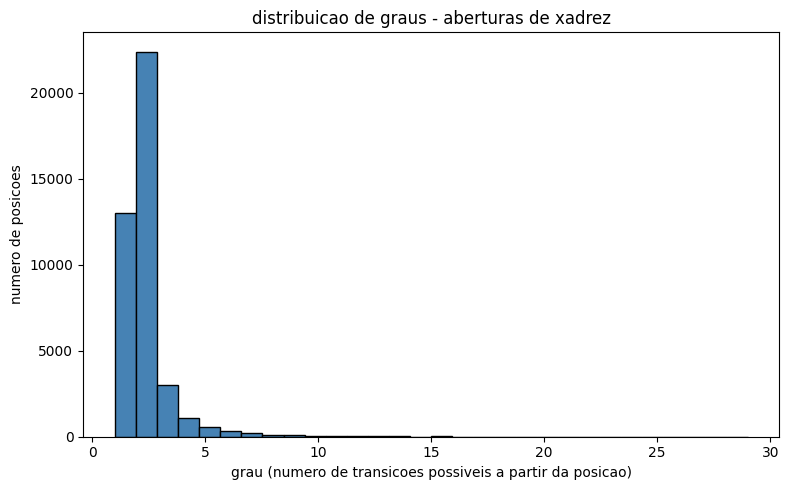


Gráfico salvo


In [9]:
graus = [grau for _, grau in G.degree()]

plt.figure(figsize=(8, 5))
plt.hist(graus, bins=30, color="steelblue", edgecolor="black")
plt.title("distribuicao de graus - aberturas de xadrez")
plt.xlabel("grau (numero de transicoes possiveis a partir da posicao)")
plt.ylabel("numero de posicoes")
plt.tight_layout()
plt.savefig("distribuicao_graus.png", dpi=150)
plt.show()

print("\nGráfico salvo")

6. Resumo pra consolidar as três redes analisadas, para facilitar a comparação e a montagem de slides:

In [13]:
resumo = pd.DataFrame({
    "rede": ["Real", "Aleatoria (Erdos-Renyi)", "Pequeno Mundo (Watts-Strogatz)"],
    "ordem": [ordem, G_random.number_of_nodes(), G_small_world.number_of_nodes()],
    "tamanho": [tamanho, G_random.number_of_edges(), G_small_world.number_of_edges()],
    "coef. Agrupamento": [coef_agrupamento, coef_agrupamento_rand, coef_agrupamento_sw],
    "densidade": [densidade, densidade_rand, densidade_sw],})
print(resumo)

                             rede  ordem  tamanho  coef. Agrupamento  \
0                            Real  40970    40969           0.000000   
1         Aleatoria (Erdos-Renyi)  40970    40969           0.000111   
2  Pequeno Mundo (Watts-Strogatz)  40970    40970           0.000000   

   densidade  
0   0.000049  
1   0.000049  
2   0.000049  


Conclusão: A rede de aberturas de xadrez apresenta uma estrutura essencialmente de árvore, o que explica por que suas métricas de agrupamento se aproximam de zero — tanto na rede real quanto nos modelos de comparação (aleatório e pequeno mundo). Diferente de redes sociais ou biológicas, aqui não há ciclos possíveis por construção, já que cada posição é alcançada por um único caminho de lances. Isso mostra que a assinatura de "mundo pequeno" (clustering alto + caminhos curtos) não é universal — ela depende da estrutura subjacente do fenômeno representado pela rede.